# Importación de librerías

In [138]:
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import hdbscan

from sklearn.cluster import KMeans, OPTICS, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

from sklearn.manifold import TSNE
import umap

# Importación de datos

In [139]:
planetas = pd.read_csv("planetas.csv", comment='#')

# Exploración de datos

Primero, revisamos los valores faltantes de las columnas a utilizar:

In [140]:
planetas[['pl_rade','pl_bmasse','pl_orbper','pl_eqt','pl_orbsmax','pl_insol',"pl_orbeccen","pl_insol", "pl_dens"]].isna().sum()

,0
pl_rade,61
pl_bmasse,42
pl_orbper,344
pl_eqt,1609
pl_orbsmax,439
pl_insol,1884
pl_orbeccen,1063
pl_insol,1884
pl_dens,150


Revisamos la correlación de las columnas en general

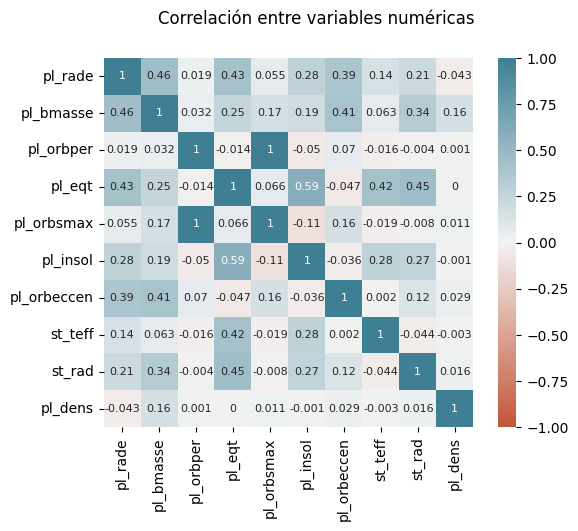

In [141]:
numeric_cols = [
    'pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_eqt', 'pl_orbsmax', 'pl_insol', 'pl_orbeccen',
    'st_teff', 'st_rad', 'pl_dens'
]

planetas = planetas.loc[:, ["pl_name"] + numeric_cols]

sns.heatmap(
    round(planetas[numeric_cols].corr(), 3),
    vmin = -1, vmax = 1, center = 0,
    cmap = sns.diverging_palette(20, 220, n = 256),
    annot = True,
    annot_kws={'fontsize': 8},
    square = True
)

plt.suptitle("Correlación entre variables numéricas")
plt.show()

In [142]:
def plot_column(col, title):
  fig, axs = plt.subplots(figsize=(10, 5), ncols=2)
  sns.histplot(planetas[col], ax=axs[0])
  sns.boxplot(planetas[col], ax=axs[1], orient='h')
  plt.suptitle(title)
  plt.savefig(f"{title}.png")
  plt.show()

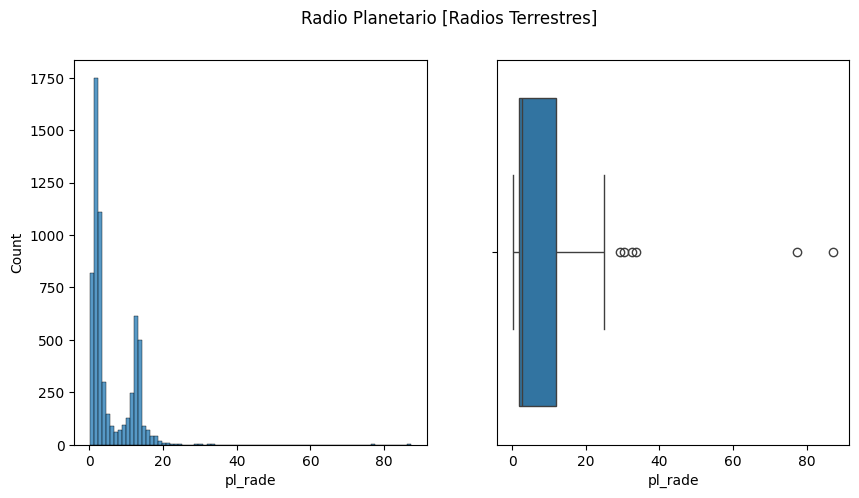

In [143]:
col = "pl_rade"
title = "Radio Planetario [Radios Terrestres]"

plot_column(col, title)
planetas = planetas[planetas["pl_rade"] < 40]

Observando que los outliers son aquellos que se encuentran por encima de 40, decidimos removerlos

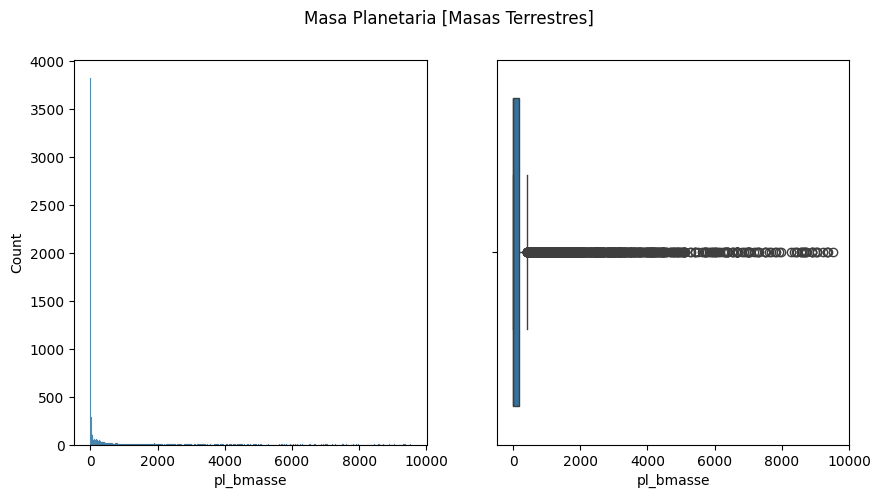

In [144]:
col = "pl_bmasse"
title = "Masa Planetaria [Masas Terrestres]"

plot_column(col, title)

A pesar de la rara distribución, no quitamos nada porque termina quitando demasiados datos

In [145]:
q = planetas['pl_orbper'].quantile(0.99)
planetas = planetas[planetas['pl_orbper'] < q]
planetas['pl_orbper'].describe()

,pl_orbper
count,5817.000000
mean,231.726587
std,968.541991
min,0.112007
25%,4.263742
50%,10.456233
75%,35.473580
max,13921.423020


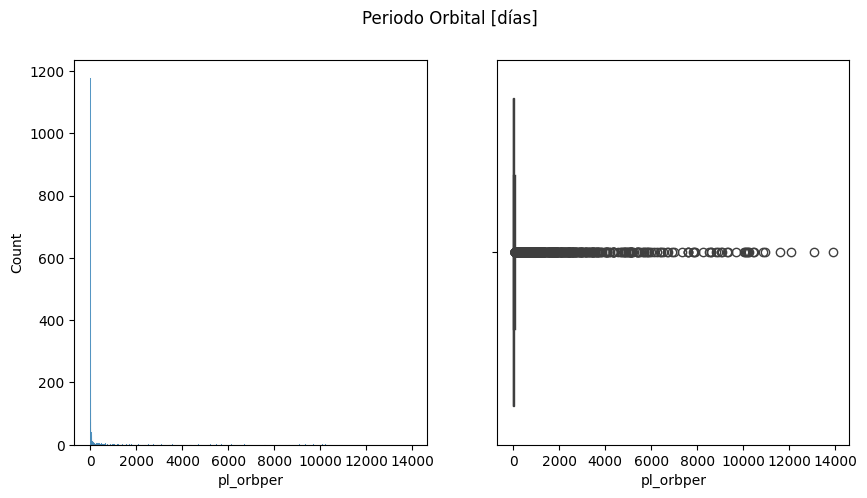

In [146]:
col = "pl_orbper"
title = "Periodo Orbital [días]"

plot_column(col, title)

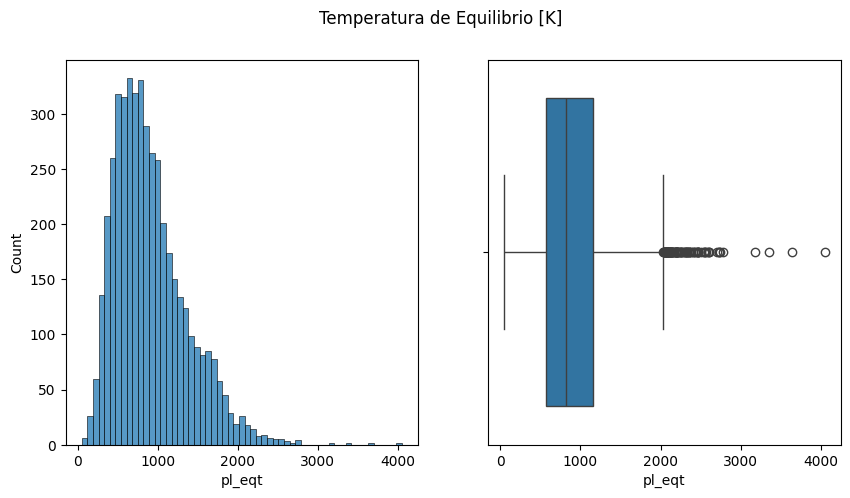

In [147]:
col = "pl_eqt"
title = "Temperatura de Equilibrio [K]"

plot_column(col, title)

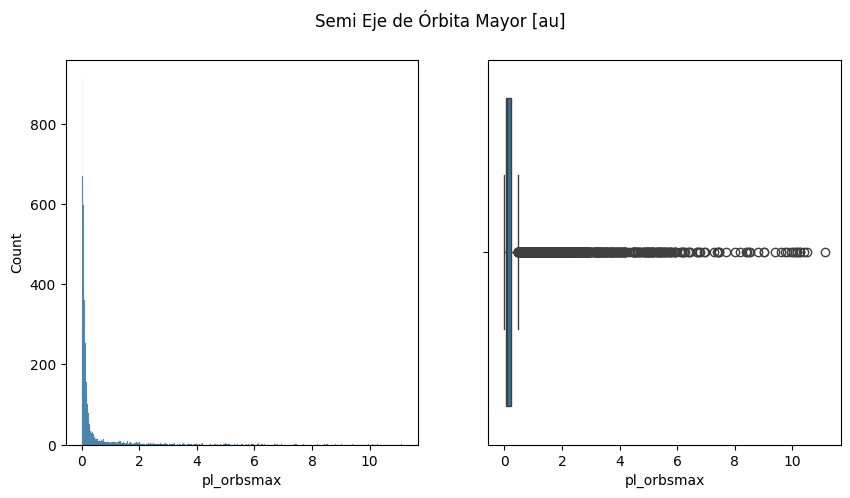

In [148]:
col = "pl_orbsmax"
title = "Semi Eje de Órbita Mayor [au]"

plot_column(col, title)

In [149]:
print(f"Planetas que quedan: {len(planetas)}")

Planetas que quedan: 5817


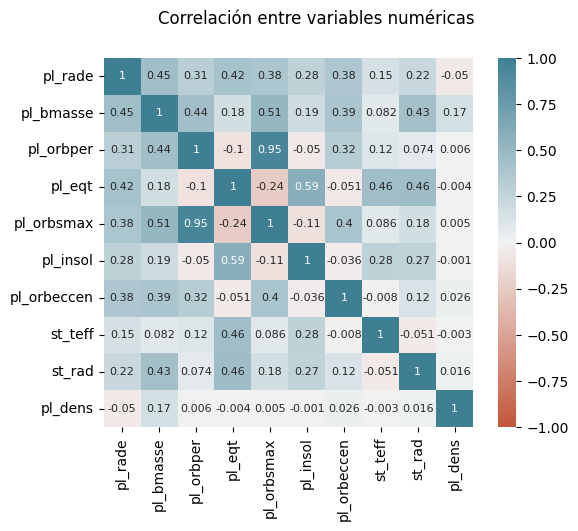

In [150]:
sns.heatmap(
    round(planetas[numeric_cols].corr(), 3),
    vmin = -1, vmax = 1, center = 0,
    cmap = sns.diverging_palette(20, 220, n = 256),
    annot = True,
    annot_kws={'fontsize': 8},
    square = True
)

plt.suptitle("Correlación entre variables numéricas")
plt.savefig("Correlación de variables.png")
plt.show()

# Preprocesamiento de datos

Se hizo una clasificación de exoplanetas por tipo según la masa:

In [151]:
def clasificar(row):
    r = row['pl_rade']
    m = row['pl_bmasse']

    if pd.isna(r) and pd.isna(m):
        return 'Sin clasificar'

    if not pd.isna(r):
        if r < 1.25:   return 'Terrestre'
        elif r < 2.0:  return 'Super-Tierra'
        elif r < 4.0:  return 'Sub-Neptuno'
        elif r < 10.0: return 'Neptuniano'
        else:          return 'Gigante gaseoso'

#checar masas, especialmente las obtenidas por velocidad radial
    if not pd.isna(m):
        if m < 2:    return 'Terrestre'
        elif m < 10: return 'Super-Tierra'
        elif m < 20: return 'Sub-Neptuno'
        elif m < 50: return 'Neptuniano'
        else:        return 'Gigante gaseoso'

planetas['tipo_planeta'] = planetas.apply(clasificar, axis=1)
print(planetas['tipo_planeta'].value_counts())

tipo_planeta
Sub-Neptuno        2036
Gigante gaseoso    1479
Super-Tierra       1179
Terrestre           571
Neptuniano          552
Name: count, dtype: int64


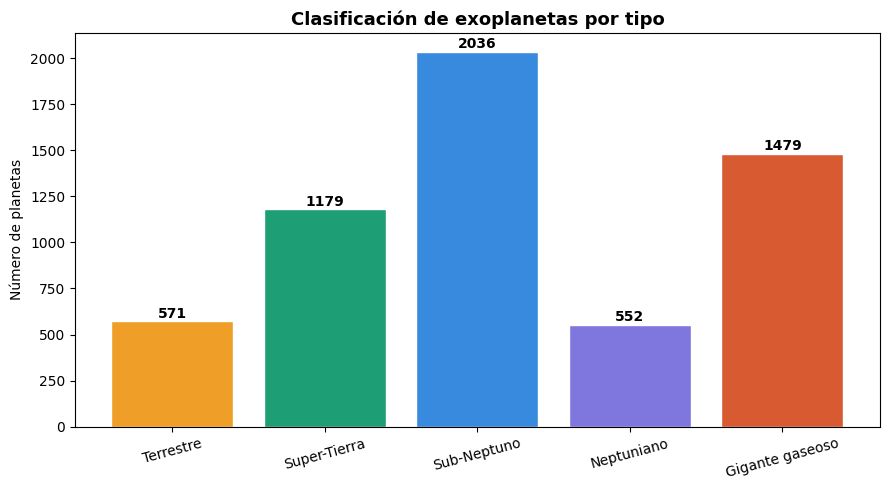

In [152]:
conteo = planetas['tipo_planeta'].value_counts()

colores = {
    'Terrestre':       '#EF9F27',
    'Super-Tierra':    '#1D9E75',
    'Sub-Neptuno':     '#378ADD',
    'Neptuniano':      '#7F77DD',
    'Gigante gaseoso': '#D85A30',
    'Sin clasificar':  '#888780'
}

orden = ['Terrestre', 'Super-Tierra', 'Sub-Neptuno', 'Neptuniano', 'Gigante gaseoso']
valores = [conteo[t] for t in orden]
colores_ord = [colores[t] for t in orden]

plt.figure(figsize=(9, 5))
bars = plt.bar(orden, valores, color=colores_ord, edgecolor='white')

for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=10, fontweight='bold')

plt.title('Clasificación de exoplanetas por tipo', fontsize=13, fontweight='bold')
plt.ylabel('Número de planetas')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("Clasificación de exoplanetas.png")
plt.show()

In [153]:
print(planetas[planetas['tipo_planeta'] == 'Sin clasificar']['pl_name'])
# 7 planetas sin clasificar

Series([], Name: pl_name, dtype: object)


Revisamos las temperaturas de equilibrio faltantes para cada tipo de planeta

In [154]:
# Equilibrium Temperature [K]
print(planetas.groupby('tipo_planeta')['pl_eqt'].apply(lambda x: x.isna().sum()))

tipo_planeta
Gigante gaseoso    710
Neptuniano         129
Sub-Neptuno        233
Super-Tierra        97
Terrestre           54
Name: pl_eqt, dtype: int64


Ahora, vamos a calcular la temperatura de la estrella

In [155]:
# Stellar Effective Temperature [K]
print(f"Faltantes st_teff:\t{planetas['st_teff'].isna().sum()}")
# Stellar Radius [Solar Radius]
print(f"Faltantes st_rad:\t{planetas['st_rad'].isna().sum()}")
# Orbit Semi-Major Axis [au]
print(f"Faltantes pl_orbsmax:\t{planetas['pl_orbsmax'].isna().sum()}")

Faltantes st_teff:	30
Faltantes st_rad:	43
Faltantes pl_orbsmax:	413


In [156]:
mask = planetas['st_teff'].notna() & planetas['st_rad'].notna() & planetas['pl_orbsmax'].notna()
print(f"Planetas con las 3 variables completas: {mask.sum()}")
print(f"Planetas sin al menos una: {(~mask).sum()}")

Planetas con las 3 variables completas: 5358
Planetas sin al menos una: 459


In [157]:
def calcular_temp_eq(row):
    # Si ya tiene temperatura medida, la dejamos
    if not pd.isna(row['pl_eqt']):
        return row['pl_eqt']

    # Si tiene las 3 variables, calculamos con la fórmula
    if not pd.isna(row['st_teff']) and not pd.isna(row['st_rad']) and not pd.isna(row['pl_orbsmax']):
        A = 0.3
        T_star = row['st_teff']
        R_star = row['st_rad'] * 6.957e8  # radios solares a metros
        r = row['pl_orbsmax'] * 1.496e11  # AU a metros
        T_eq = T_star * ((R_star / (2 * r)) ** 0.5) * ((1 - A) ** 0.25)
        return T_eq

    return np.nan

planetas['pl_eqt'] = planetas.apply(calcular_temp_eq, axis=1)
print(f"Después de la fórmula, faltantes: {planetas['pl_eqt'].isna().sum()}")

Después de la fórmula, faltantes: 238


De los planetas que aún tiene un valor faltante, revisamos cuáles tienen flujo en unidades solares:

In [158]:
# T_eq = 278.5 * (F)^0.25   donde F es el flujo en unidades solares
# F = Insolation Flux [Earth Flux]
sin_temp = planetas['pl_eqt'].isna()
print(f"Planetas CON flujo: {(sin_temp & planetas['pl_insol'].notna()).sum()}")
print(f"Planetas SIN flujo: {(sin_temp & planetas['pl_insol'].isna()).sum()}")

Planetas CON flujo: 0
Planetas SIN flujo: 238


Imputamos los datos faltantes por medio de KNN

In [159]:
num_df = planetas.loc[:, numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

imputer = KNNImputer(n_neighbors=5)
X_scaled_imputed = imputer.fit_transform(X_scaled)

X_imputed = scaler.inverse_transform(X_scaled_imputed)

planetas.loc[:, numeric_cols] = X_imputed

In [160]:
planetas = planetas.dropna(subset=['pl_eqt'])
print(f"Planetas restantes: {len(planetas)}")

Planetas restantes: 5817


# Construcción de modelos

Normalización de los datos para la aplicación de los algoritmos de clustering

In [161]:
num_df = planetas.loc[:, numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

In [162]:
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# X_pos = tsne.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2)
X_pos = reducer.fit_transform(X_scaled)

planetas['x'] = X_pos[:, 0]
planetas['y'] = X_pos[:, 1]

In [163]:
cols_clustering = ['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_eqt', 'pl_orbsmax']
X_clustering_data = planetas[cols_clustering]
X = X_clustering_data.dropna()
idx = X.index

## K-Means

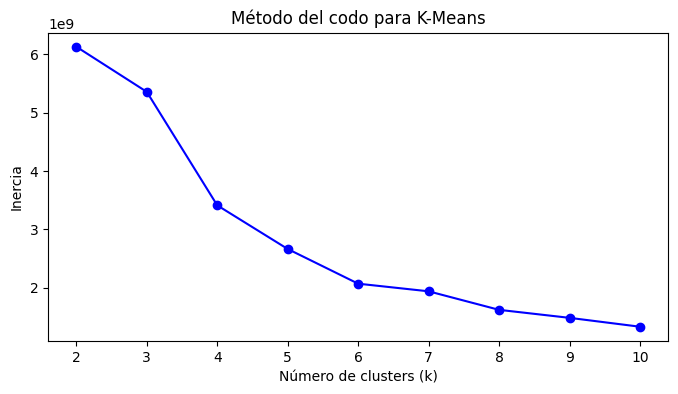

In [164]:
inercias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inercias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para K-Means')
plt.show()

In [165]:
for k in range(2, 31):
    clusterer = KMeans(n_clusters=k)
    labels = clusterer.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{k},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	2,	Silhouette:0.645	CHS: 1547.980
k=3 -> Clústeres: 	3,	Silhouette:0.458	CHS: 1286.862
k=4 -> Clústeres: 	4,	Silhouette:0.465	CHS: 1235.664
k=5 -> Clústeres: 	5,	Silhouette:0.487	CHS: 1113.525
k=6 -> Clústeres: 	6,	Silhouette:0.245	CHS: 1106.973
k=7 -> Clústeres: 	7,	Silhouette:0.250	CHS: 1172.876
k=8 -> Clústeres: 	8,	Silhouette:0.279	CHS: 1213.761
k=9 -> Clústeres: 	9,	Silhouette:0.297	CHS: 1413.625
k=10 -> Clústeres: 	10,	Silhouette:0.263	CHS: 1259.303
k=11 -> Clústeres: 	11,	Silhouette:0.311	CHS: 1344.621
k=12 -> Clústeres: 	12,	Silhouette:0.470	CHS: 1397.630
k=13 -> Clústeres: 	13,	Silhouette:0.286	CHS: 1454.647
k=14 -> Clústeres: 	14,	Silhouette:0.287	CHS: 1405.935
k=15 -> Clústeres: 	15,	Silhouette:0.296	CHS: 1499.434
k=16 -> Clústeres: 	16,	Silhouette:0.300	CHS: 1397.005
k=17 -> Clústeres: 	17,	Silhouette:0.285	CHS: 1453.690
k=18 -> Clústeres: 	18,	Silhouette:0.299	CHS: 1468.312
k=19 -> Clústeres: 	19,	Silhouette:0.296	CHS: 1433.635
k=20 -> Clústeres: 	20,	Si

In [166]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)
planetas.loc[idx, 'cluster_kmeans'] = labels

print(planetas['cluster_kmeans'].value_counts())

cluster_kmeans
0.0    5568
1.0     249
Name: count, dtype: int64


In [167]:
cols_ver = ['cluster_kmeans', 'pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_eqt']

print(planetas.groupby('cluster_kmeans')[cols_ver[1:]].median().round(2))

                pl_rade  pl_bmasse  pl_orbper  pl_eqt
cluster_kmeans                                       
0.0                2.63       7.94       9.84  770.06
1.0               12.50    3003.37    2990.00  156.50


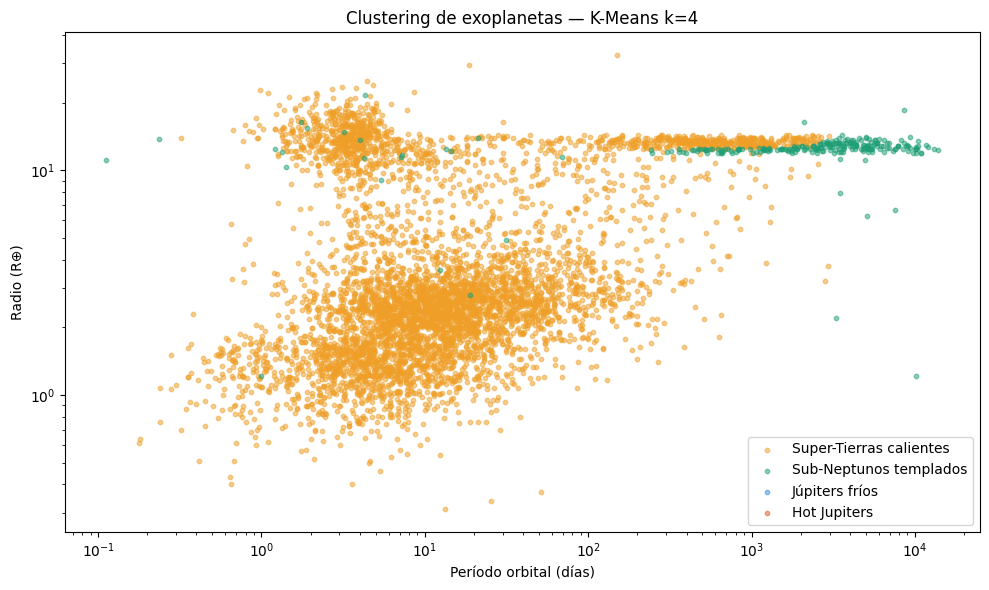

In [168]:
colores = {
    0.0: '#EF9F27',
    1.0: '#1D9E75',
    2.0: '#378ADD',
    3.0: '#D85A30'
}

nombres = {
    0.0: 'Super-Tierras calientes',
    1.0: 'Sub-Neptunos templados',
    2.0: 'Júpiters fríos',
    3.0: 'Hot Jupiters'
}

fig, ax = plt.subplots(figsize=(10, 6))

for cluster in [0.0, 1.0, 2.0, 3.0]:
    sub = planetas[planetas['cluster_kmeans'] == cluster]
    ax.scatter(sub['pl_orbper'], sub['pl_rade'],
               c=colores[cluster], s=10, alpha=0.5,
               label=nombres[cluster])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Período orbital (días)')
ax.set_ylabel('Radio (R⊕)')
ax.set_title('Clustering de exoplanetas — K-Means k=4')
ax.legend()
plt.tight_layout()
plt.show()

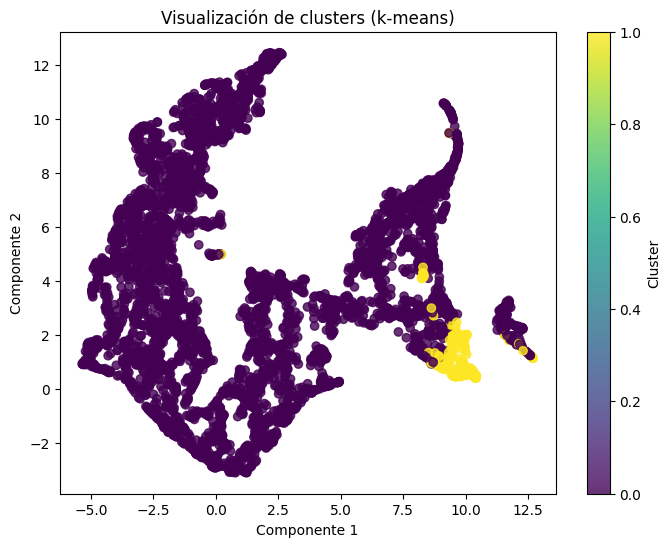

In [169]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (k-means)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("k-means.png")
plt.show()

In [170]:
silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

Silueta: 0.704866699612042
Calinski-Harabasz: 1354.2346196308793


Counter({np.int32(1): 249, np.int32(0): 5568})

Para habitabilidad buscamos:
- Energía recibida (T_eq/insolación hay agua líquida)
- Tipo de planeta
- Masa (si puede tener atmósfera)
  Hay que calcular las masas que no tenemos. Podemos checar si los que no tiene masa, tienen semi eje mayor a. a3=R2M, donde R es periodo orbital (ver si lo tienen) y M es la masa. En caso de que sea posible calcularlo, lo hacemos. Si no, eliminamos los datos.
- Excentricidad orbital (estabilidad térmica)

## OPTICS

In [171]:
for k in range(5, 12):
    clusterer = OPTICS(min_samples=k, xi=0.1)
    labels = clusterer.fit_predict(X_scaled)

    # Excluir puntos etiquetados como ruido (-1)
    mask = labels != -1
    if np.sum(mask) == 0:
        print(f"k={k} -> Solo ruido, no se puede calcular silhouette")
        continue

    labels_filtered = labels[mask]
    X_filtered = X_scaled[mask]

    # Número de clústeres reales (excluyendo -1)
    n_clusters = len(set(labels_filtered))
    if n_clusters < 2:
        print(f"k={k} -> Un solo clúster ({n_clusters}), silhouette no definida")
        continue

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{n_clusters},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=5 -> Clústeres: 	60,	Silhouette:-0.661	CHS: 7.729
k=6 -> Clústeres: 	38,	Silhouette:-0.638	CHS: 9.205
k=7 -> Clústeres: 	19,	Silhouette:-0.615	CHS: 6.096
k=8 -> Clústeres: 	7,	Silhouette:-0.525	CHS: 6.719
k=9 -> Un solo clúster (1), silhouette no definida
k=10 -> Un solo clúster (1), silhouette no definida
k=11 -> Un solo clúster (1), silhouette no definida


In [172]:
optics = OPTICS(min_samples=10, xi=0.1)
labels = optics.fit_predict(X_scaled)

# Número de clústeres detectados (sin ruido)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Clústeres: {n_clusters}, Ruido: {sum(labels==-1)}")
print(f"Silueta: {silhouette}")

Clústeres: 1, Ruido: 5805
Silueta: -0.5252875042036976


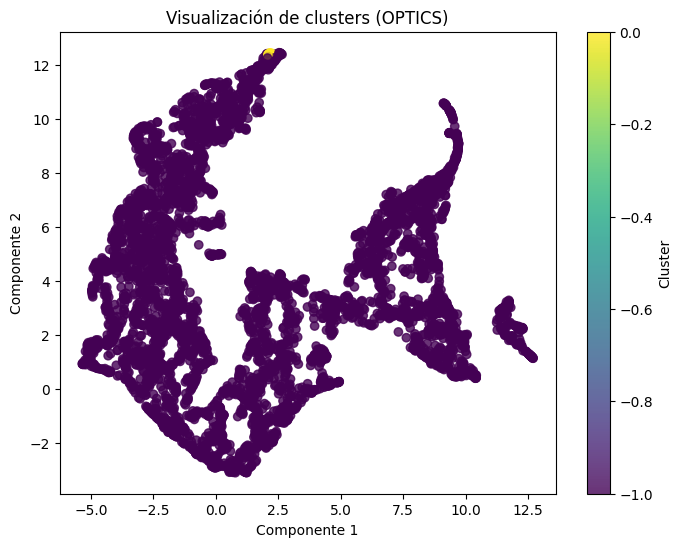

In [173]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (OPTICS)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("optics.png")
plt.show()

In [174]:
silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

Silueta: 0.15125137680444792
Calinski-Harabasz: 10.117173505959293


Counter({np.int64(-1): 5805, np.int64(0): 12})

## HDBSCAN

In [175]:
for k in range(2, 100, 2):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=k)
    labels = clusterer.fit_predict(X_scaled)

    # Excluir puntos etiquetados como ruido (-1)
    mask = labels != -1
    if np.sum(mask) == 0:
        print(f"k={k} -> Solo ruido, no se puede calcular silhouette")
        continue

    labels_filtered = labels[mask]
    X_filtered = X_scaled[mask]

    # Número de clústeres reales (excluyendo -1)
    n_clusters = len(set(labels_filtered))
    if n_clusters < 2:
        print(f"k={k} -> Un solo clúster ({n_clusters}), silhouette no definida")
        continue

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{n_clusters},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	616,	Silhouette:-0.312	CHS: 5.401
k=4 -> Clústeres: 	2,	Silhouette:0.826	CHS: 299.771
k=6 -> Clústeres: 	23,	Silhouette:-0.226	CHS: 29.589
k=8 -> Clústeres: 	14,	Silhouette:-0.195	CHS: 45.025
k=10 -> Clústeres: 	9,	Silhouette:-0.136	CHS: 62.647
k=12 -> Clústeres: 	5,	Silhouette:0.148	CHS: 203.522
k=14 -> Clústeres: 	3,	Silhouette:0.212	CHS: 329.881
k=16 -> Clústeres: 	3,	Silhouette:0.206	CHS: 321.516
k=18 -> Clústeres: 	3,	Silhouette:0.207	CHS: 321.126
k=20 -> Clústeres: 	3,	Silhouette:0.208	CHS: 320.067
k=22 -> Clústeres: 	3,	Silhouette:0.214	CHS: 326.769
k=24 -> Clústeres: 	3,	Silhouette:0.213	CHS: 323.398
k=26 -> Clústeres: 	3,	Silhouette:0.197	CHS: 307.669
k=28 -> Clústeres: 	3,	Silhouette:0.201	CHS: 313.489
k=30 -> Clústeres: 	2,	Silhouette:0.244	CHS: 474.023
k=32 -> Clústeres: 	2,	Silhouette:0.243	CHS: 471.254
k=34 -> Clústeres: 	2,	Silhouette:0.244	CHS: 472.961
k=36 -> Clústeres: 	2,	Silhouette:0.246	CHS: 474.112
k=38 -> Clústeres: 	2,	Silhouette:0.243	CHS: 47

In [176]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=68)
labels = clusterer.fit_predict(X_scaled)

# Resultados
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
print(f"Clústeres encontrados: {n_clusters}")
print(f"Puntos ruido: {n_noise}")


Clústeres encontrados: 2
Puntos ruido: 2085


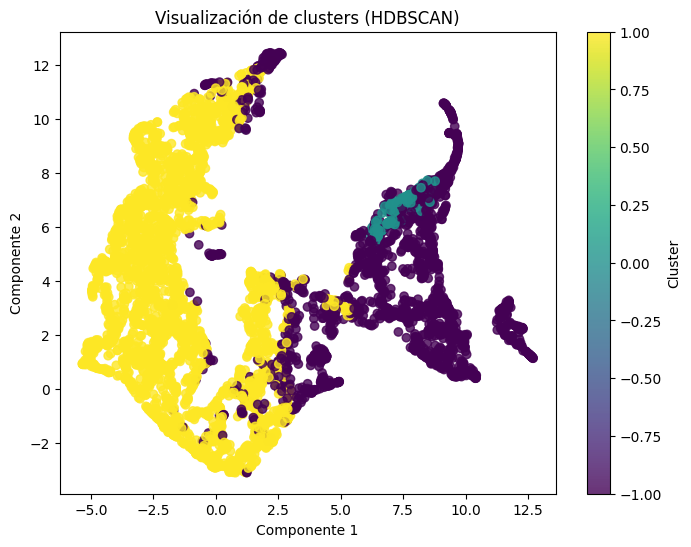

In [177]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (HDBSCAN)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("hdbscan.png")
plt.show()

In [178]:
silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

Silueta: 0.25130376540958405
Calinski-Harabasz: 482.43962165649305


Counter({np.int64(-1): 2085, np.int64(0): 189, np.int64(1): 3543})

## Clustering Aglomerativo

### Single

In [179]:
for k in range(2, 10):
    clusterer = AgglomerativeClustering(n_clusters=k, linkage="single")
    labels = clusterer.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{k},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	2,	Silhouette:0.946	CHS: 343.274
k=3 -> Clústeres: 	3,	Silhouette:0.850	CHS: 217.592
k=4 -> Clústeres: 	4,	Silhouette:0.851	CHS: 250.094
k=5 -> Clústeres: 	5,	Silhouette:0.852	CHS: 255.378
k=6 -> Clústeres: 	6,	Silhouette:0.851	CHS: 217.866
k=7 -> Clústeres: 	7,	Silhouette:0.826	CHS: 228.338
k=8 -> Clústeres: 	8,	Silhouette:0.826	CHS: 223.785
k=9 -> Clústeres: 	9,	Silhouette:0.826	CHS: 196.187


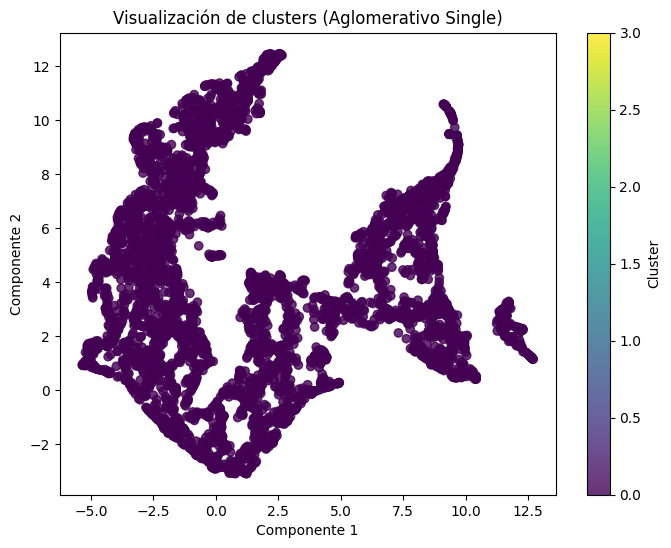

Silueta: 0.8508020481320281
Calinski-Harabasz: 250.0939848398423


Counter({np.int64(0): 5812, np.int64(1): 2, np.int64(3): 1, np.int64(2): 2})

In [180]:
clusterer = AgglomerativeClustering(n_clusters=4, linkage="single")
labels = clusterer.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (Aglomerativo Single)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("Agglomerative single.png")
plt.show()

silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

### Average

In [181]:
for k in range(2, 10):
    clusterer = AgglomerativeClustering(n_clusters=k, linkage="average")
    labels = clusterer.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{k},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	2,	Silhouette:0.946	CHS: 343.274
k=3 -> Clústeres: 	3,	Silhouette:0.903	CHS: 346.198
k=4 -> Clústeres: 	4,	Silhouette:0.861	CHS: 309.139
k=5 -> Clústeres: 	5,	Silhouette:0.854	CHS: 374.728
k=6 -> Clústeres: 	6,	Silhouette:0.851	CHS: 314.881
k=7 -> Clústeres: 	7,	Silhouette:0.827	CHS: 272.507
k=8 -> Clústeres: 	8,	Silhouette:0.827	CHS: 236.775
k=9 -> Clústeres: 	9,	Silhouette:0.787	CHS: 337.208


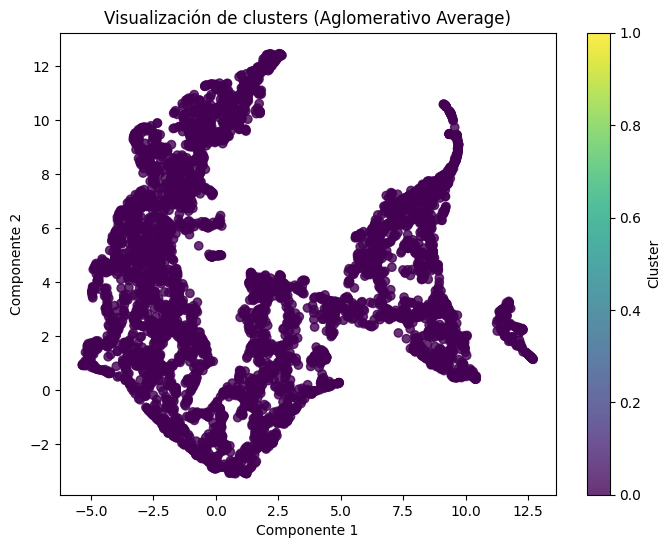

Silueta: 0.9457143282849059
Calinski-Harabasz: 343.2739913371306


Counter({np.int64(0): 5816, np.int64(1): 1})

In [182]:
clusterer = AgglomerativeClustering(n_clusters=2, linkage="average")
labels = clusterer.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (Aglomerativo Average)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("Agglomerative average.png")
plt.show()

silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

### Ward

In [183]:
for k in range(2, 10):
    clusterer = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = clusterer.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{k},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	2,	Silhouette:0.676	CHS: 1394.360
k=3 -> Clústeres: 	3,	Silhouette:0.405	CHS: 1215.055
k=4 -> Clústeres: 	4,	Silhouette:0.411	CHS: 1131.842
k=5 -> Clústeres: 	5,	Silhouette:0.417	CHS: 1114.189
k=6 -> Clústeres: 	6,	Silhouette:0.421	CHS: 1121.955
k=7 -> Clústeres: 	7,	Silhouette:0.421	CHS: 1158.832
k=8 -> Clústeres: 	8,	Silhouette:0.423	CHS: 1173.907
k=9 -> Clústeres: 	9,	Silhouette:0.426	CHS: 1190.476


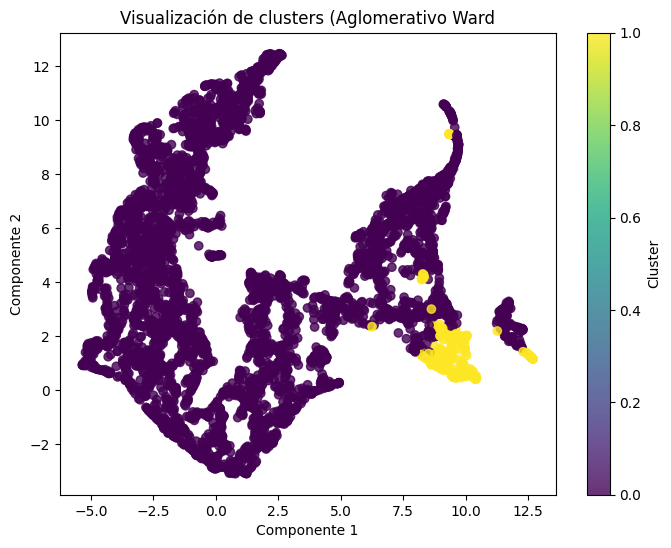

Silueta: 0.6759884143225228
Calinski-Harabasz: 1394.3604865795678


Counter({np.int64(0): 5506, np.int64(1): 311})

In [184]:
clusterer = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels = clusterer.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (Aglomerativo Ward')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("Agglomerative ward.png")
plt.show()

silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

In [185]:
planetas['densidad_gcm3'] = 5.51 * (planetas['pl_bmasse'] / (planetas['pl_rade'] ** 3))


# Criterio de habitabilidad

\**Criterio de habitabilidad **
Radio 0.5 R_T - 2 R_T
Masa 0.1 M_T - 10 M_T
Densidad 3-7 g/cm3
Temperatura de equilibrio  275 K < Teq< 315 K
Excentricidad <0.3
 era este ?

In [186]:
def es_habitable(row):
    if not (0.5 <= row['pl_rade'] <= 2):
        return False

    if not (0.1 <= row['pl_bmasse'] <= 10):
        return False

    if pd.isna(row['pl_orbeccen']) or row['pl_orbeccen'] > 0.3:
        return False

    if pd.isna(row['densidad_gcm3']) or not (3 <= row['densidad_gcm3'] <= 7):
        return False

    if pd.notna(row['pl_insol']):
        if not (0.75 <= row['pl_insol'] <= 1.5):
            return False
    elif pd.notna(row['pl_eqt']):
        if not (275 <= row['pl_eqt'] <= 315):
            return False
    else:
        return False

    return True

planetas['habitable'] = planetas.apply(es_habitable, axis=1)
print(f"Planetas potencialmente habitables: {planetas['habitable'].sum()}")




Planetas potencialmente habitables: 21


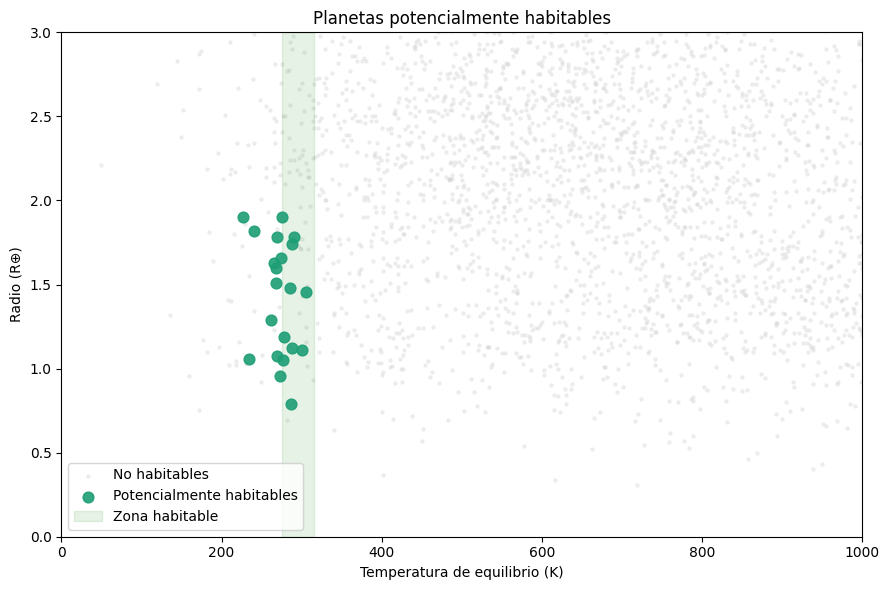

In [187]:
fig, ax = plt.subplots(figsize=(9, 6))

# Todos los planetas
ax.scatter(planetas['pl_eqt'], planetas['pl_rade'],
           c='lightgray', s=5, alpha=0.3, label='No habitables')

# Habitables
hab = planetas[planetas['habitable'] == True]
ax.scatter(hab['pl_eqt'], hab['pl_rade'],
           c='#1D9E75', s=60, alpha=0.9, label='Potencialmente habitables', zorder=5)

# Zona habitable
ax.axvspan(275, 315, alpha=0.1, color='green', label='Zona habitable')

ax.set_xlabel('Temperatura de equilibrio (K)')
ax.set_ylabel('Radio (R⊕)')
ax.set_title('Planetas potencialmente habitables')
ax.set_xlim(0, 1000)
ax.set_ylim(0, 3)
ax.legend()
plt.tight_layout()
plt.show()

In [188]:
habitables = planetas[planetas['habitable'] == True][['pl_name', 'pl_rade', 'pl_bmasse', 'pl_eqt', 'pl_orbeccen', 'pl_orbper', 'tipo_planeta']].sort_values('pl_eqt')

print(habitables.to_string(index=False))

           pl_name  pl_rade  pl_bmasse     pl_eqt  pl_orbeccen  pl_orbper tipo_planeta
        K2-288 B b    1.900      4.270 226.360000      0.11900  31.393463 Super-Tierra
     Kepler-1649 c    1.060      1.200 234.000000      0.00000  19.535270    Terrestre
      Kepler-283 c    1.820      3.970 240.000000      0.00000  92.743711 Super-Tierra
           K2-72 e    1.290      2.210 261.913924      0.11000  24.158868 Super-Tierra
      Kepler-452 b    1.630      3.290 265.000000      0.00000 384.843000 Super-Tierra
          GJ 273 b    1.510      2.890 267.516491      0.10000  18.649800 Super-Tierra
     Kepler-1652 b    1.600      3.190 268.000000      0.00000  38.097220 Super-Tierra
         TOI-700 d    1.073      1.250 268.800000      0.04200  37.423960    Terrestre
     Kepler-1544 b    1.780      3.820 269.000000      0.00000 168.811174 Super-Tierra
         TOI-700 e    0.953      0.818 272.900000      0.05900  27.809780    Terrestre
       Wolf 1061 c    1.660      3.410 273.

'Tierra radio : 1.0 masa: 1.0, temperatura de equilibrio 288. exentricidad: 0.017, 'perido de orbitaje ': 365.25, tipo_planeta: 'Terrestre'

Como se detectan
Detection Method:
Transit

If a planet passes directly between a star and an observer's line of sight, it blocks out a tiny portion of the star's light, thus reducing its apparent brightness.

 Sensitive instruments can detect this periodic dip in brightness. From the period and depth of the transits, the orbit and size of the planetary companions can be calculated. Smaller planets will produce a smaller effect, and vice-versa. A terrestrial planet in an Earth-like orbit, for example, would produce a minute dip in stellar brightness that would last just a few hours.

In [189]:
# Valores de referencia (Tierra)
R0 = 1.0          # radio terrestre
M0 = 1.0          # masa terrestre
D0 = 5.51         # densidad (g/cm³)
T0 = 255.0        # temperatura equilibrio (K)
E0 = 0.0167       # excentricidad

# Pesos asignados
w_r, w_m, w_d, w_t, w_e = 0.25, 0.1, 0.2, 0.4, 0.5

# Suponiendo que tu DataFrame se llama 'df'
# y tiene las columnas: pl_rade, pl_bmasse, pl_dens, pl_eqt, pl_orbeccen

# Calcular cada factor (manejando automáticamente los NaN)
f_r = (1 - np.abs(planetas['pl_rade'] - R0) / (planetas['pl_rade'] + R0)) ** w_r
f_m = (1 - np.abs(planetas['pl_bmasse'] - M0) / (planetas['pl_bmasse'] + M0)) ** w_m
f_d = (1 - np.abs(planetas['pl_dens'] - D0) / (planetas['pl_dens'] + D0)) ** w_d
f_t = (1 - np.abs(planetas['pl_eqt'] - T0) / (planetas['pl_eqt'] + T0)) ** w_t
f_e = (1 - np.abs(planetas['pl_orbeccen'] - E0) / (planetas['pl_orbeccen'] + E0)) ** w_e

# Producto final (será NaN si alguna columna tiene NaN)
planetas['ESI_mod'] = f_r * f_m * f_d * f_t * f_e

# Habitabilidad
conditions = [
    planetas['ESI_mod'] > 0.8,
    planetas['ESI_mod'] > 0.6,
    planetas['ESI_mod'] > 0.3,
    planetas['ESI_mod'] <= 0.3
]
choices = ['Habitabilidad máxima', 'Potencialmente habitable', 'Poco habitable', 'No habitable']

planetas['habitabilidad'] = np.select(conditions, choices, default='Sin datos')

# Clasificación de planetas

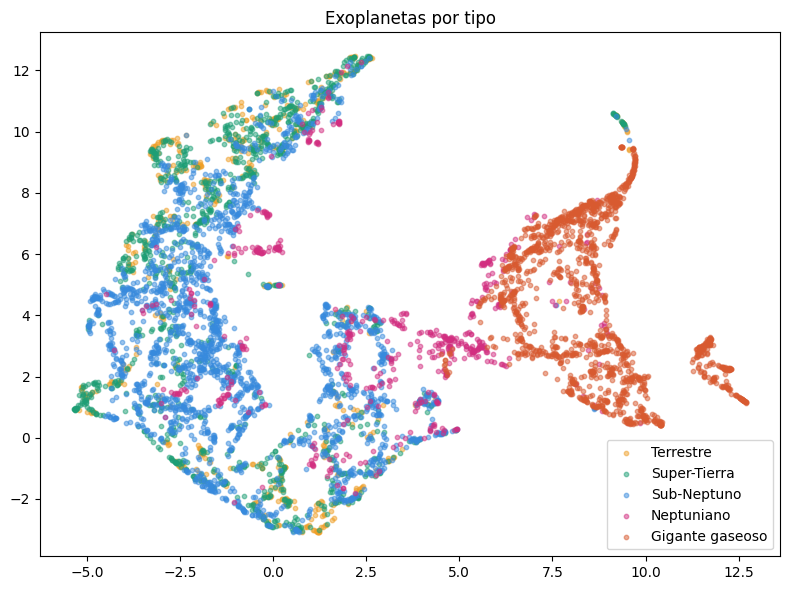

In [190]:
colores = ['#EF9F27', '#1D9E75', '#378ADD', '#D22E80', '#D85A30', '#888780']
nombres = ['Terrestre', 'Super-Tierra', 'Sub-Neptuno', 'Neptuniano', 'Gigante gaseoso']

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(5):
    sub = planetas[planetas["tipo_planeta"] == nombres[i]]
    ax.scatter(sub['x'], sub['y'],
               c=colores[i], s=10, alpha=0.5,
               label=nombres[i])

ax.set_title('Exoplanetas por tipo')
ax.legend()
plt.tight_layout()
plt.savefig("Exoplanetas Tipo.png")
plt.show()

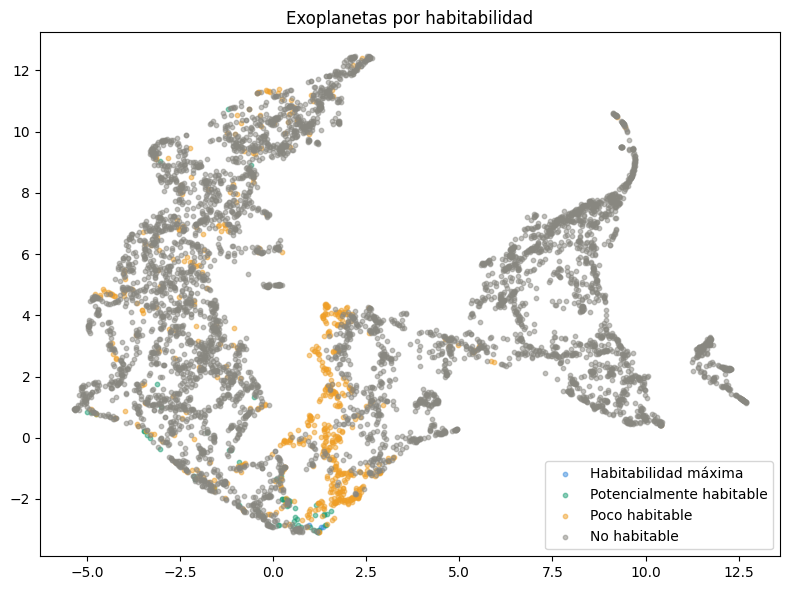

In [191]:
colores = ['#378ADD', '#1D9E75', '#EF9F27', '#888780']
nombres = ['Habitabilidad máxima', 'Potencialmente habitable', 'Poco habitable', 'No habitable']

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(4):
    sub = planetas[planetas["habitabilidad"] == nombres[i]]
    ax.scatter(sub['x'], sub['y'],
               c=colores[i], s=10, alpha=0.5,
               label=nombres[i])

ax.set_title('Exoplanetas por habitabilidad')
ax.legend()
plt.tight_layout()
plt.savefig("Exoplanetas Habitabilidad.png")
plt.show()